# Importing Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import MinMaxScaler, LabelEncoder


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Karunya\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Karunya\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Karunya\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Karunya\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Karunya\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Karunya\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



# Loading the Dataset

In [2]:
df = pd.read_csv('data.csv')
print(f"Uploaded dataset into dataframe having shape {df.shape}")

Uploaded dataset into dataframe having shape (116, 10)


# Exploring the Dataframe

## Dimension and Size

In [3]:
print(f"No. of Rows : {df.shape[0]}\nNo. of Columns : {df.shape[1]}")
print("Total No. of Elements : ", df.size)

No. of Rows : 116
No. of Columns : 10
Total No. of Elements :  1160


## Displaying Samples

In [4]:
print("First 5 rows")
display(df.head())

First 5 rows


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [5]:
print("Last 5 rows")
display(df.tail())

Last 5 rows


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
111,45,26.85,92,3.33,0.755688,54.68,12.10,10.96,268.23,2
112,62,26.84,100,4.53,1.117400,12.45,21.42,7.32,330.16,2
113,65,32.05,97,5.73,1.370998,61.48,22.54,10.33,314.05,2
114,72,25.59,82,2.82,0.570392,24.96,33.75,3.27,392.46,2
115,86,27.18,138,19.91,6.777364,90.28,14.11,4.35,90.09,2


In [6]:
print("Randomly selected rows")
display(df.sample(5))

Randomly selected rows


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
44,71,30.300000,102,8.340,2.098344,56.5020,8.130000,4.29890,200.976,1
36,66,31.238590,82,4.181,0.845677,16.2247,4.267105,3.29175,634.602,1
34,51,27.688778,77,3.855,0.732193,20.0920,3.192090,10.37518,473.859,1
52,45,21.303949,102,13.852,3.485163,7.6476,21.056625,23.03408,552.444,2
87,85,27.688778,196,51.814,25.050342,70.8824,7.901685,55.21530,1078.359,2


## Metadata

In [7]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             116 non-null    int64  
 1   BMI             116 non-null    float64
 2   Glucose         116 non-null    int64  
 3   Insulin         116 non-null    float64
 4   HOMA            116 non-null    float64
 5   Leptin          116 non-null    float64
 6   Adiponectin     116 non-null    float64
 7   Resistin        116 non-null    float64
 8   MCP.1           116 non-null    float64
 9   Classification  116 non-null    object 
dtypes: float64(7), int64(2), object(1)
memory usage: 9.2+ KB


None

## Statistical Summary

In [8]:
display(df.describe())

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1
count,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000,116.000000
mean,57.301724,27.582111,97.793103,10.012086,2.694988,26.615080,10.180874,14.725966,534.647000
std,16.112766,5.020136,22.525162,10.067768,3.642043,19.183294,6.843341,12.390646,345.912663
min,24.000000,18.370000,60.000000,2.432000,0.467409,4.311000,1.656020,3.210000,45.843000
25%,45.000000,22.973205,85.750000,4.359250,0.917966,12.313675,5.474283,6.881763,269.978250
50%,56.000000,27.662416,92.000000,5.924500,1.380939,20.271000,8.352692,10.827740,471.322500
75%,71.000000,31.241442,102.000000,11.189250,2.857787,37.378300,11.815970,17.755207,700.085000
max,89.000000,38.578759,201.000000,58.460000,25.050342,90.280000,38.040000,82.100000,1698.440000


# Data Preprocessing

## Identifying Null Values

In [9]:
display(df.isnull())

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
111,False,False,False,False,False,False,False,False,False,False
112,False,False,False,False,False,False,False,False,False,False
113,False,False,False,False,False,False,False,False,False,False
114,False,False,False,False,False,False,False,False,False,False


In [10]:
print(f"No. of NULL values per column : \n{df.isnull().sum()}\nTotal No. of NULL Values : {df.isnull().sum().sum()}")

No. of NULL values per column : 
Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    0
dtype: int64
Total No. of NULL Values : 0


## Converting to Suitable Data Types

In [11]:
df['Classification'].unique() #We did this, because it helps us to know that this feature is suitable to be converted into Category

array(['1', 'na', '2'], dtype=object)

In [12]:
df.query("Classification == 'na'")

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
16,47,22.030000,84,2.869,0.590000,26.6500,38.040000,3.32000,191.720,na
17,61,32.038959,85,18.077,3.790144,30.7729,7.780255,13.68392,444.395,na


In [13]:
(df == 'na').sum()

Age               0
BMI               0
Glucose           0
Insulin           0
HOMA              0
Leptin            0
Adiponectin       0
Resistin          0
MCP.1             0
Classification    2
dtype: int64

In [14]:
print(f"Before Dropping : {df.shape}")
df = df[df['Classification'] != 'na']
print(f"After Dropping : {df.shape}")

Before Dropping : (116, 10)
After Dropping : (114, 10)


In [15]:
df['Classification'] = df['Classification'].astype('category')

In [16]:
df.dtypes

Age                  int64
BMI                float64
Glucose              int64
Insulin            float64
HOMA               float64
Leptin             float64
Adiponectin        float64
Resistin           float64
MCP.1              float64
Classification    category
dtype: object

# Quick EDA

## Age vs Classification

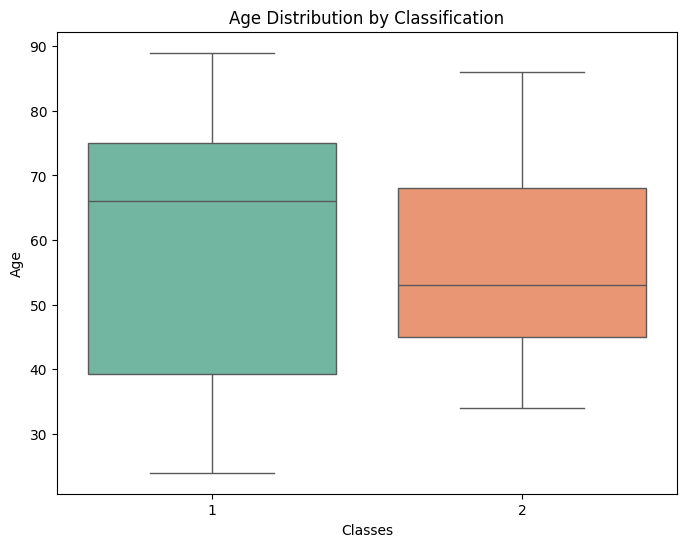

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Classification', y='Age', hue='Classification',palette='Set2')
plt.title('Age Distribution by Classification')
plt.xlabel('Classes')
plt.ylabel('Age')
plt.show()

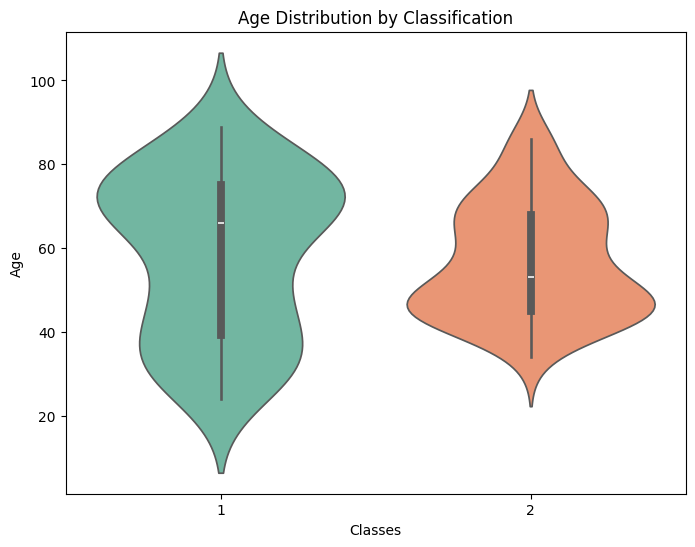

In [18]:
plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='Classification', y='Age', hue='Classification',palette='Set2')
plt.title('Age Distribution by Classification')
plt.xlabel('Classes')
plt.ylabel('Age')
plt.show()

## Correlation Matrix

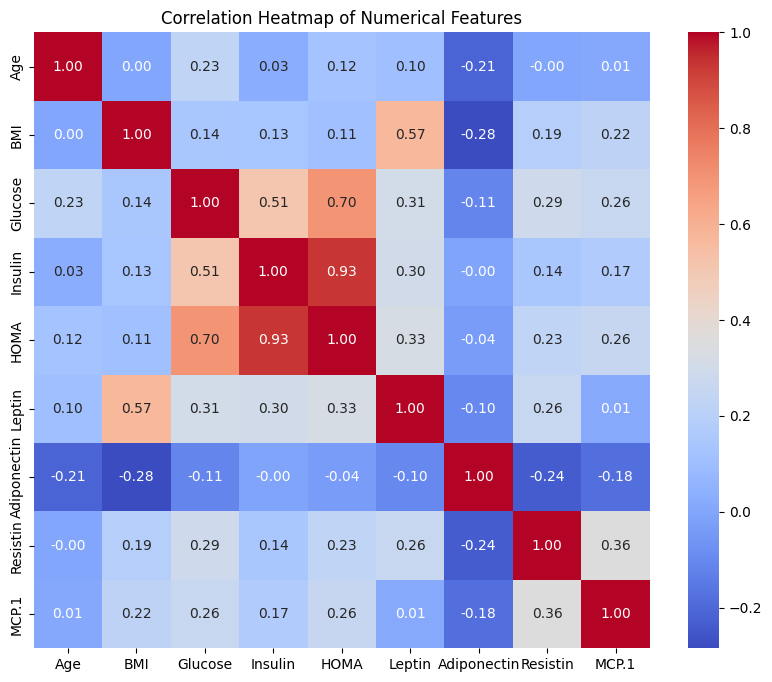

In [19]:
corr = df.drop(columns='Classification').corr() #We dropped 'Classification' because it ain't numerical type
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Feature Scaling

## Before Feature Scaling

In [20]:
print("Before scaling the Classification Feature")
display(df.sample(5))

Before scaling the Classification Feature


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
84,42,29.296875,98,4.172,1.008511,12.2617,6.695585,53.67170,1041.843,2
110,54,36.050000,119,11.910,3.495982,89.2700,8.010000,5.06000,218.280,2
12,25,22.860000,82,4.090,0.827271,20.4500,23.670000,5.14000,313.730,1
99,69,28.444444,108,8.808,2.346451,14.7485,5.288025,16.48508,353.568,2
20,36,28.576676,86,4.345,0.921719,15.1248,8.600000,9.15390,534.224,1


In [21]:
scaler = MinMaxScaler()

columns_to_scale = ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 
                    'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

## After Feature Scaling

In [22]:
print("After feature scaling, observer how values in columns have been changed")
display(df.sample(5))

After feature scaling, observer how values in columns have been changed


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
50,0.800000,0.431991,0.354610,0.424413,0.270290,0.203178,0.095327,0.066979,0.000000,1
107,0.338462,0.732851,0.226950,0.059220,0.034067,0.167258,0.218114,0.071999,0.098843,2
72,0.415385,0.000000,0.319149,0.064218,0.044517,0.061755,0.322753,0.000000,0.283080,2
69,0.307692,0.058885,0.382979,0.240201,0.162749,0.102002,0.543948,0.017873,0.105783,2
73,0.738462,0.259788,0.319149,0.035482,0.027555,0.203201,0.470991,0.020408,0.090825,2


# Turning Categorical Variables into Quantitative Variables

## Before Label Encoding

In [23]:
print(f"Before Label Encoding")
display(df.groupby('Classification').size())

Before Label Encoding


Classification
1    50
2    64
dtype: int64

In [24]:
encoder = LabelEncoder()
df['Classification'] = encoder.fit_transform(df['Classification'])

## After Label Encoding

In [25]:
print(f"After Label Encoding")
display(df.groupby('Classification').size())

After Label Encoding


Classification
0    50
1    64
dtype: int64